       SIR SIMULATION RESULTS
Basic R₀:           1.50
Effective R₀:       1.50
Epidemic spreads:   Yes
Peak infected:      6.3% (Day 104)
Total infected:     58.3%
Herd immunity need: 33.3%


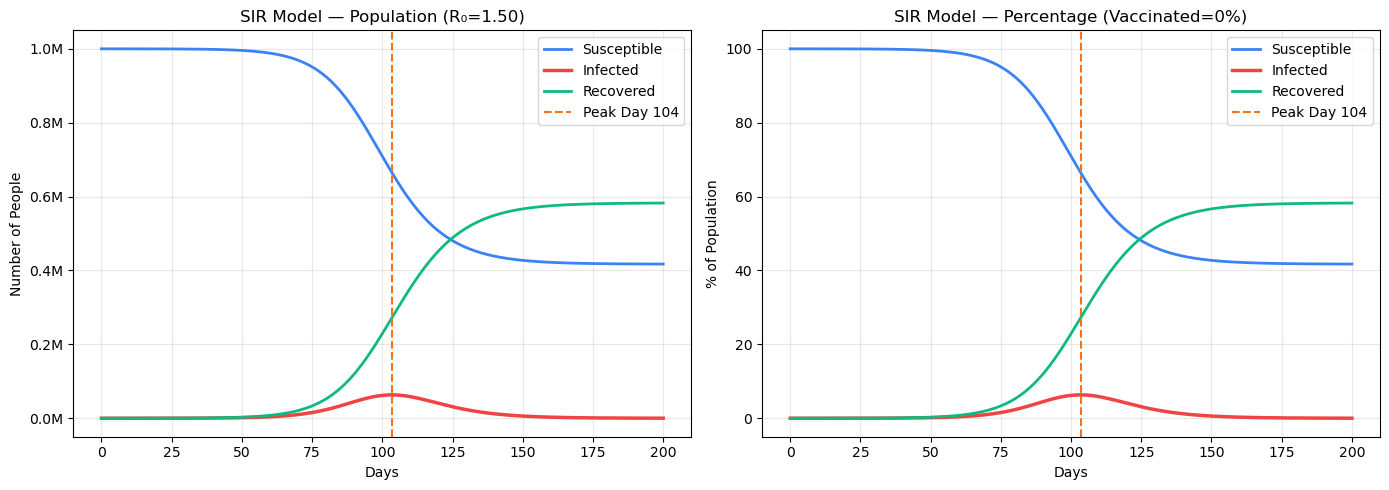

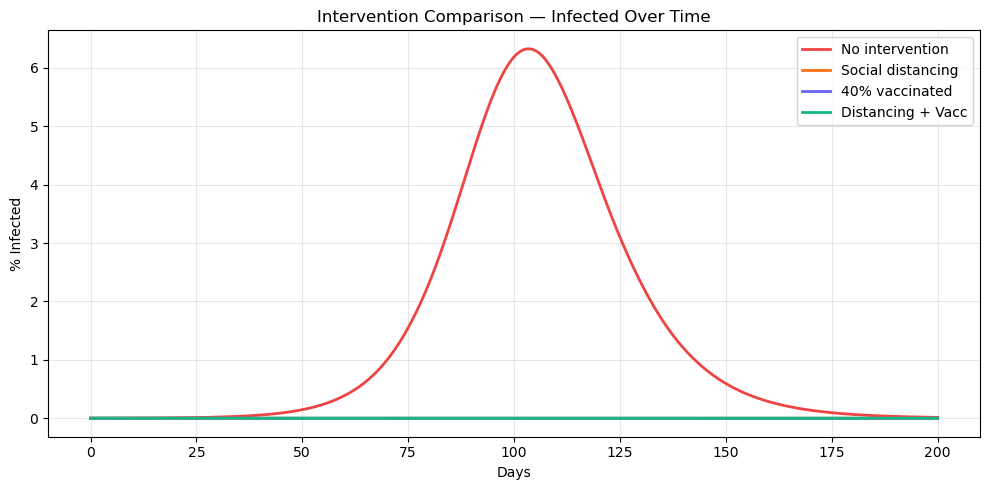

In [1]:
# ============================================================
# FLU PANDEMIC SIR SIMULATION
# pip install numpy scipy matplotlib
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ── 1. Parameters ────────────────────────────────────────────
N          = 1_000_000   # total population
I0         = 10          # initial infected
vaccination = 0.0        # vaccination coverage (0.0 to 1.0)

beta       = 0.30        # transmission rate (higher = spreads faster)
gamma      = 0.20        # recovery rate (1/gamma = avg days to recover)
days       = 200         # simulation duration

# ── 2. Initial Conditions ─────────────────────────────────────
S0      = N * (1 - vaccination) - I0   # susceptible (minus vaccinated)
R0_init = N * vaccination              # vaccinated start as recovered/immune
y0      = [S0, I0, R0_init]

# ── 3. SIR Differential Equations ────────────────────────────
def sir_model(t, y):
    S, I, R = y
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

# ── 4. Solve ──────────────────────────────────────────────────
t_span = (0, days)
t_eval = np.linspace(0, days, 1000)

sol = solve_ivp(sir_model, t_span, y0, t_eval=t_eval, method='RK45')
S, I, R = sol.y

# ── 5. Key Metrics ────────────────────────────────────────────
R0            = beta / gamma
effective_R0  = R0 * (1 - vaccination)
peak_pct      = I.max() / N * 100
peak_day      = t_eval[I.argmax()]
final_infected = R[-1] / N * 100
herd_immunity = max(0, (1 - 1 / R0) * 100)

print("=" * 40)
print("       SIR SIMULATION RESULTS")
print("=" * 40)
print(f"Basic R₀:           {R0:.2f}")
print(f"Effective R₀:       {effective_R0:.2f}")
print(f"Epidemic spreads:   {'Yes' if effective_R0 > 1 else 'No'}")
print(f"Peak infected:      {peak_pct:.1f}% (Day {peak_day:.0f})")
print(f"Total infected:     {final_infected:.1f}%")
print(f"Herd immunity need: {herd_immunity:.1f}%")
print("=" * 40)

# ── 6. Plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Population counts
ax1.plot(t_eval, S,       color='#3b82f6', lw=2,   label='Susceptible')
ax1.plot(t_eval, I,       color='#ef4444', lw=2.5, label='Infected')
ax1.plot(t_eval, R,       color='#10b981', lw=2,   label='Recovered')
ax1.axvline(peak_day,     color='#f97316', ls='--', lw=1.5, label=f'Peak Day {peak_day:.0f}')
ax1.set_xlabel('Days')
ax1.set_ylabel('Number of People')
ax1.set_title(f'SIR Model — Population (R₀={R0:.2f})')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 2: Percentage
ax2.plot(t_eval, S/N*100, color='#3b82f6', lw=2,   label='Susceptible')
ax2.plot(t_eval, I/N*100, color='#ef4444', lw=2.5, label='Infected')
ax2.plot(t_eval, R/N*100, color='#10b981', lw=2,   label='Recovered')
ax2.axvline(peak_day,     color='#f97316', ls='--', lw=1.5, label=f'Peak Day {peak_day:.0f}')
ax2.set_xlabel('Days')
ax2.set_ylabel('% of Population')
ax2.set_title(f'SIR Model — Percentage (Vaccinated={vaccination*100:.0f}%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sir_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. Intervention Comparison ────────────────────────────────
scenarios = [
    {"label": "No intervention",    "beta": 0.30, "vacc": 0.00},
    {"label": "Social distancing",  "beta": 0.18, "vacc": 0.00},
    {"label": "40% vaccinated",     "beta": 0.30, "vacc": 0.40},
    {"label": "Distancing + Vacc",  "beta": 0.18, "vacc": 0.40},
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ef4444', '#f97316', '#6366f1', '#10b981']

for sc, color in zip(scenarios, colors):
    S0_ = N * (1 - sc["vacc"]) - I0
    R0_ = N * sc["vacc"]
    def model(t, y, b=sc["beta"]):
        S, I, R = y
        return [-b*S*I/N, b*S*I/N - gamma*I, gamma*I]
    sol_ = solve_ivp(model, t_span, [S0_, I0, R0_], t_eval=t_eval)
    ax.plot(t_eval, sol_.y[1]/N*100, color=color, lw=2, label=sc["label"])

ax.set_xlabel('Days')
ax.set_ylabel('% Infected')
ax.set_title('Intervention Comparison — Infected Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sir_interventions.png', dpi=150, bbox_inches='tight')
plt.show()

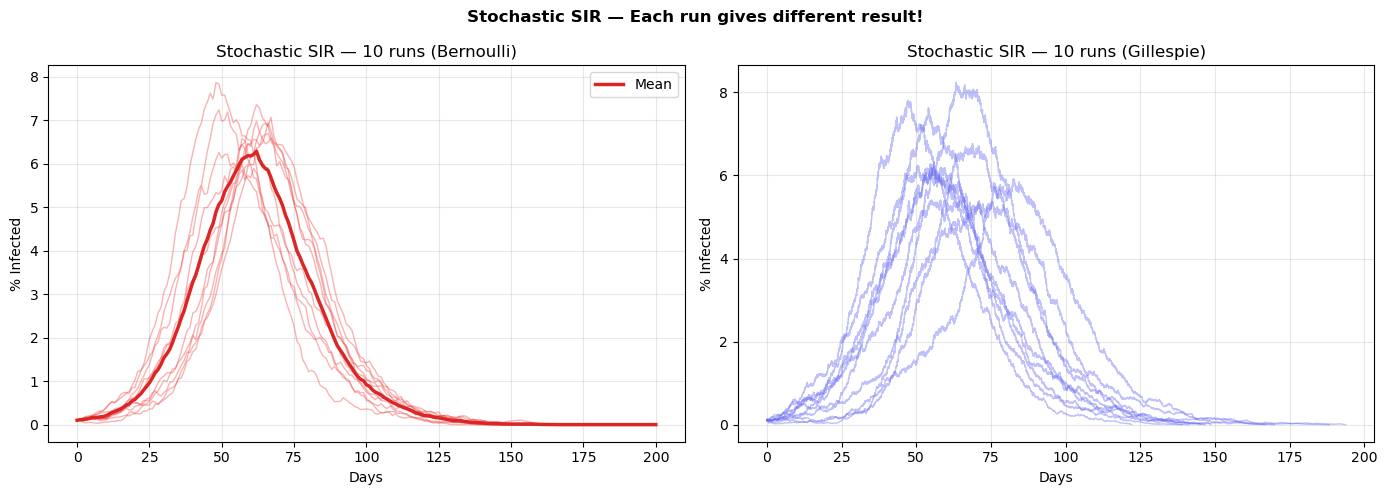

Peak infected — Mean: 6.9%  Std: 0.5%
              Min:  5.9%  Max: 7.9%


In [2]:
# ============================================================
# STOCHASTIC SIR MODEL — Using Random Numbers
# pip install numpy matplotlib
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────
N     = 10_000    # population (smaller for stochastic)
I0    = 10        # initial infected
beta  = 0.30      # transmission rate
gamma = 0.20      # recovery rate
days  = 200       # simulation days
runs  = 10        # number of simulation runs

# ============================================================
# METHOD 1: Simple Random (Bernoulli trials)
# Each person has a probability of getting infected or recovering
# ============================================================
def stochastic_sir(N, I0, beta, gamma, days):
    S, I, R = N - I0, I0, 0
    history = {'S': [S], 'I': [I], 'R': [R]}

    for _ in range(days):
        # ── Probability of each event happening ───────────────
        p_infection = beta * I / N   # prob a susceptible gets infected
        p_recovery  = gamma          # prob an infected person recovers

        # ── Random draws — how many people transition? ────────
        new_infected  = np.random.binomial(S, p_infection)  # S people, each with p_infection chance
        new_recovered = np.random.binomial(I, p_recovery)   # I people, each with p_recovery chance

        # ── Update compartments ───────────────────────────────
        S -= new_infected
        I += new_infected - new_recovered
        R += new_recovered

        # ── Ensure no negatives ───────────────────────────────
        S = max(0, S)
        I = max(0, I)

        history['S'].append(S)
        history['I'].append(I)
        history['R'].append(R)

    return history

# ============================================================
# METHOD 2: Gillespie Algorithm (more accurate)
# Simulates exact timing of each infection/recovery event
# ============================================================
def gillespie_sir(N, I0, beta, gamma, max_time=200):
    S, I, R = N - I0, I0, 0
    t = 0
    history = {'t': [0], 'S': [S], 'I': [I], 'R': [R]}

    while t < max_time and I > 0:
        # ── Calculate rates of each event ─────────────────────
        rate_infection = beta * S * I / N
        rate_recovery  = gamma * I
        total_rate     = rate_infection + rate_recovery

        if total_rate == 0:
            break

        # ── Random time until next event (exponential distribution) ──
        dt = np.random.exponential(1 / total_rate)
        t += dt

        # ── Random draw — which event happens? ────────────────
        if np.random.random() < rate_infection / total_rate:
            S -= 1   # infection event
            I += 1
        else:
            I -= 1   # recovery event
            R += 1

        history['t'].append(t)
        history['S'].append(S)
        history['I'].append(I)
        history['R'].append(R)

    return history

# ============================================================
# STEP 3: Run Multiple Simulations
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot Method 1: Multiple runs ──────────────────────────────
t = np.arange(days + 1)
all_infected = []

for i in range(runs):
    result = stochastic_sir(N, I0, beta, gamma, days)
    infected = np.array(result['I']) / N * 100
    all_infected.append(infected)
    ax1.plot(t, infected, alpha=0.4, lw=1, color='#ef4444')

# Plot mean across all runs
mean_infected = np.mean(all_infected, axis=0)
ax1.plot(t, mean_infected, color='#dc2626', lw=2.5, label='Mean')
ax1.set_xlabel('Days')
ax1.set_ylabel('% Infected')
ax1.set_title(f'Stochastic SIR — {runs} runs (Bernoulli)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot Method 2: Gillespie ──────────────────────────────────
for i in range(runs):
    result = gillespie_sir(N, I0, beta, gamma)
    ax2.plot(result['t'],
             np.array(result['I']) / N * 100,
             alpha=0.4, lw=1, color='#6366f1')

ax2.set_xlabel('Days')
ax2.set_ylabel('% Infected')
ax2.set_title(f'Stochastic SIR — {runs} runs (Gillespie)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Stochastic SIR — Each run gives different result!', fontweight='bold')
plt.tight_layout()
plt.savefig('stochastic_sir.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats across runs ─────────────────────────────────
peaks = [max(r) for r in all_infected]
print(f"Peak infected — Mean: {np.mean(peaks):.1f}%  Std: {np.std(peaks):.1f}%")
print(f"              Min:  {np.min(peaks):.1f}%  Max: {np.max(peaks):.1f}%")